In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
f = 5   
points_3D = np.array([
    [0, 0, 5],
    [1, 1, 5],
    [-1, 1, 6],
    [1, -1, 7],
    [-1, -1, 6]
])

In [4]:
X, Y, Z = points_3D[:,0], points_3D[:,1], points_3D[:,2]
x_proj = f * X / Z
y_proj = f * Y / Z
z_proj = np.ones_like(x_proj) * f   

points_proj = np.column_stack((x_proj, y_proj, z_proj))

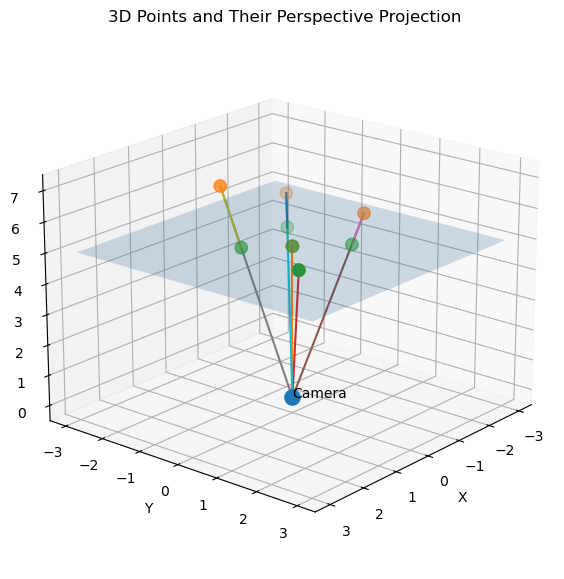

In [11]:
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')

# Camera
ax.scatter(0, 0, 0, s=120)
ax.text(0,0,0,"Camera")

# 3D points
ax.scatter(points_3D[:,0], points_3D[:,1], points_3D[:,2], s=80)

# Image plane
xx, yy = np.meshgrid(np.linspace(-3,3,2), np.linspace(-3,3,2))
zz = np.ones_like(xx) * f
ax.plot_surface(xx, yy, zz, alpha=0.2)

# Projected points
ax.scatter(points_proj[:,0], points_proj[:,1], points_proj[:,2], s=80)

# Rays from camera to points
for p3, pp in zip(points_3D, points_proj):
    ax.plot([0, p3[0]], [0, p3[1]], [0, p3[2]])
    ax.plot([p3[0], pp[0]], [p3[1], pp[1]], [p3[2], pp[2]])

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Points and Their Perspective Projection")

ax.view_init(elev=20, azim=40)

plt.show()